In [122]:
!pip install biopython

In [123]:
%pip install GEOparse

In [124]:
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

Dataset Retrieval

In [125]:
# Load 1st Dataset containing AD patients
gse1 = GEOparse.get_GEO(geo="GSE48350", destdir="./")

02-Apr-2026 06:38:05 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
02-Apr-2026 06:38:05 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
02-Apr-2026 06:38:05 INFO GEOparse - Parsing ./GSE48350_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE48350_family.soft.gz: 
02-Apr-2026 06:38:05 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
02-Apr-2026 06:38:05 DEBUG GEOparse - SERIES: GSE48350
DEBUG:GEOparse:SERIES: GSE48350
02-Apr-2026 06:38:05 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
02-Apr-2026 06:38:14 DEBUG GEOparse - SAMPLE: GSM300166
DEBUG:GEOparse:SAMPLE: GSM300166
02-Apr-2026 06:38:14 DEBUG GEOparse 

In [126]:
# Extract expression data and metadata
expression_data1 = gse1.pivot_samples('VALUE')
metadata1 = gse1.phenotype_data

In [127]:
print(expression_data1.shape)
print(metadata1.columns)

(54675, 253)
Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.individual',
       'characteristics_ch1.1.brain region', 'characteristics_ch1.2.gender',
       'characteristics_ch1.3.age (yrs)', 'treatment_protocol_ch1',
       'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1',
       'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol',
       'description', 'data_processing', 'platform_id', 'contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'relation', 'series_id',
       'data_row_count', 'characteristics_ch1.0.gender',
       'characteristics_ch1.1.age (yrs)', 'characteristics_ch1.2.brain region',
       'cha

In [128]:
#Drop Unnecessary Columns
columns_to_drop1 = ['contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country']
metadatadrop1 = metadata1.drop(columns=columns_to_drop1)

In [129]:
print(metadatadrop1.head())

                                               title geo_accession  \
GSM300166      PostcentralGyrus_female_91yrs_indiv10     GSM300166   
GSM300167  SuperiorFrontalGyrus_female_91yrs_indiv10     GSM300167   
GSM300168          Hippocampus_female_96yrs_indiv105     GSM300168   
GSM300169            Hippocampus_male_82yrs_indiv106     GSM300169   
GSM300170            Hippocampus_male_84yrs_indiv108     GSM300170   

                          status submission_date last_update_date type  \
GSM300166  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300167  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300168  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300169  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300170  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   

          channel_count                                  source_name_ch1  \
GSM300166             1       brain, postcentral gyrus, fe

In [130]:
# Load 2nd Dataset containing Normal/Control Patients
gse2 = GEOparse.get_GEO(geo="GSE11882", destdir="./")

02-Apr-2026 06:39:30 DEBUG utils - Directory ./ already exists. Skipping.
DEBUG:GEOparse:Directory ./ already exists. Skipping.
02-Apr-2026 06:39:30 INFO GEOparse - File already exist: using local version.
INFO:GEOparse:File already exist: using local version.
02-Apr-2026 06:39:30 INFO GEOparse - Parsing ./GSE11882_family.soft.gz: 
INFO:GEOparse:Parsing ./GSE11882_family.soft.gz: 
02-Apr-2026 06:39:30 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
02-Apr-2026 06:39:30 DEBUG GEOparse - SERIES: GSE11882
DEBUG:GEOparse:SERIES: GSE11882
02-Apr-2026 06:39:30 DEBUG GEOparse - PLATFORM: GPL570
DEBUG:GEOparse:PLATFORM: GPL570
/usr/local/lib/python3.12/dist-packages/GEOparse/GEOparse.py:401: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  return read_csv(StringIO(data), index_col=None, sep="\t")
02-Apr-2026 06:39:32 DEBUG GEOparse - SAMPLE: GSM300166
DEBUG:GEOparse:SAMPLE: GSM300166
02-Apr-2026 06:39:32 DEBUG GEOparse 

In [131]:
# Extract expression data and metadata
expression_data2 = gse2.pivot_samples('VALUE')
metadata2 = gse2.phenotype_data

In [132]:
print(metadata2.columns)

Index(['title', 'geo_accession', 'status', 'submission_date',
       'last_update_date', 'type', 'channel_count', 'source_name_ch1',
       'organism_ch1', 'taxid_ch1', 'characteristics_ch1.0.individual',
       'characteristics_ch1.1.brain region', 'characteristics_ch1.2.gender',
       'characteristics_ch1.3.age (yrs)', 'treatment_protocol_ch1',
       'growth_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1',
       'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol',
       'description', 'data_processing', 'platform_id', 'contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country', 'supplementary_file', 'relation', 'series_id',
       'data_row_count'],
      dtype='object')


In [133]:
# Drop Unnecessary Columns
columns_to_drop2 = ['contact_name',
       'contact_email', 'contact_phone', 'contact_laboratory',
       'contact_department', 'contact_institute', 'contact_address',
       'contact_city', 'contact_state', 'contact_zip/postal_code',
       'contact_country']
metadatadrop2 = metadata2.drop(columns=columns_to_drop2)

In [134]:
print(metadatadrop2.head())

                                               title geo_accession  \
GSM300166      PostcentralGyrus_female_91yrs_indiv10     GSM300166   
GSM300167  SuperiorFrontalGyrus_female_91yrs_indiv10     GSM300167   
GSM300168          Hippocampus_female_96yrs_indiv105     GSM300168   
GSM300169            Hippocampus_male_82yrs_indiv106     GSM300169   
GSM300170            Hippocampus_male_84yrs_indiv108     GSM300170   

                          status submission_date last_update_date type  \
GSM300166  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300167  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300168  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300169  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   
GSM300170  Public on Oct 09 2008     Jun 25 2008      Jun 26 2019  RNA   

          channel_count                                  source_name_ch1  \
GSM300166             1       brain, postcentral gyrus, fe

In [135]:
# Find common genes between the two datasets
common_genes = expression_data1.index.intersection(expression_data2.index)
expr1 = expression_data1.loc[common_genes]
expr2 = expression_data2.loc[common_genes]

In [136]:
# Combined Expression data and Metadata
combined_expr = pd.concat([expr1, expr2], axis=1)
combined_meta = pd.concat([metadatadrop1, metadatadrop2], axis=0)

In [137]:
# Access platform annotations
platform = gse1.gpls['GPL570'].table

In [138]:
print(platform)

                    ID  GB_ACC    SPOT_ID Species Scientific Name  \
0            1007_s_at  U48705        NaN            Homo sapiens   
1              1053_at  M87338        NaN            Homo sapiens   
2               117_at  X51757        NaN            Homo sapiens   
3               121_at  X69699        NaN            Homo sapiens   
4            1255_g_at  L36861        NaN            Homo sapiens   
...                ...     ...        ...                     ...   
54670   AFFX-ThrX-5_at     NaN  --Control            Homo sapiens   
54671   AFFX-ThrX-M_at     NaN  --Control            Homo sapiens   
54672  AFFX-TrpnX-3_at     NaN  --Control            Homo sapiens   
54673  AFFX-TrpnX-5_at     NaN  --Control            Homo sapiens   
54674  AFFX-TrpnX-M_at     NaN  --Control            Homo sapiens   

      Annotation Date      Sequence Type                  Sequence Source  \
0         Oct 6, 2014  Exemplar sequence  Affymetrix Proprietary Database   
1         Oct 6, 

In [139]:
# Correctly assign disease status
combined_meta['braak_stage'] = combined_meta['characteristics_ch1.3.braak stage'].fillna('Not available')
def assign_label(row):
    stage = row['braak_stage']
    if stage in ['III', 'IV', 'V', 'VI']:
        return 'AD'
    elif stage in ['0', 'I', 'II']:
        return 'Normal'
    elif 'cognitively intact' in str(row.get('description', '')).lower():
        return 'Normal'
    else:
        return None  # unknown — don't guess

combined_meta['disease_status'] = combined_meta.apply(assign_label, axis=1)

In [140]:
print("Label distribution:\n", combined_meta['disease_status'].value_counts(dropna=False))
print("\nUnlabelled samples:", combined_meta['disease_status'].isna().sum())

Label distribution:
 disease_status
Normal    351
AD         68
None        7
Name: count, dtype: int64

Unlabelled samples: 7


In [141]:
# Define genes of interest and their probes from platform GPL570
gene_probes = {
    'APOE': ['203381_s_at', '203382_s_at', '212884_x_at'],
    'APP': ['200602_at', '201981_at', '201982_s_at'],
    'PSEN1': ['1559206_at', '1567440_at', '1567443_x_at'],
    'PSEN2': ['204261_s_at', '204262_s_at', '211373_s_at'],
    'TREM2': ['219725_at'],
    'MAPT': ['203928_x_at', '203929_s_at', '203930_s_at']
}

In [142]:
# Calculate mean expression for each gene
gene_expr = {}
for gene in gene_probes.keys():
    available_probes = [p for p in gene_probes[gene] if p in combined_expr.index]
    gene_expr[gene] = combined_expr.loc[available_probes].mean(axis=0)
gene_expr_df = pd.DataFrame(gene_expr)

In [143]:
# Extract and clean metadata features
combined_meta['age'] = combined_meta['characteristics_ch1.3.age (yrs)'].str.extract(r'(\d+)').astype(float)
combined_meta['sex'] = combined_meta['characteristics_ch1.2.gender'].str.strip().map({'male': 0, 'female': 1})
combined_meta['brain_area'] = combined_meta['characteristics_ch1.1.brain region'].str.extract(r'brain region: (\w+)')

In [144]:
# Encode categorical variables
combined_meta['sex'] = combined_meta['sex'].fillna(0.5)
brain_area_dummies = pd.get_dummies(combined_meta['brain_area'], prefix='brain_area')

In [145]:
combined_meta = combined_meta.dropna(subset=['disease_status'])
gene_expr_df = gene_expr_df.loc[gene_expr_df.index.isin(combined_meta.index)]
brain_area_dummies = brain_area_dummies.loc[brain_area_dummies.index.isin(combined_meta.index)]

In [146]:
# Reset indices to avoid duplicates
combined_meta = combined_meta.reset_index(drop=True)
brain_area_dummies = brain_area_dummies.reset_index(drop=True)
gene_expr_df = gene_expr_df.reset_index(drop=True)

# Combine all features
features = pd.concat([combined_meta[['age', 'sex']], brain_area_dummies, gene_expr_df], axis=1)

# Remove any rows with missing values
features = features.dropna()

# Get target (assuming disease_status is in combined_meta)
target = combined_meta.loc[features.index, 'disease_status'].map({'Normal': 0, 'AD': 1})

In [147]:
print("combined_meta index:", combined_meta.index.tolist())
print("gene_expr_df index:", gene_expr_df.index.tolist())
print("brain_area_dummies index:", brain_area_dummies.index.tolist())

combined_meta index: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217

In [148]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Now concat and get target
features = pd.concat([combined_meta[['age', 'sex']], brain_area_dummies, gene_expr_df], axis=1)
target = combined_meta['disease_status'].map({'Normal': 0, 'AD': 1})

# Now mask works cleanly since all indices are 0,1,2,...
mask = target.notna()
features = features[mask]
target = target[mask]

# Split FIRST
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.5, random_state=42, stratify=target)

# THEN fit imputer on training data only
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train = X_train.copy()
X_test = X_test.copy()

# Numerical columns
num_cols = ['age', 'sex'] + list(gene_expr_df.columns)
cat_cols = []
X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])   # transform only, no fit

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("Label balance in train:\n", y_train.value_counts())

Training set shape: (209, 8)
Testing set shape: (210, 8)
Label balance in train:
 disease_status
0    175
1     34
Name: count, dtype: int64


In [149]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [151]:
y_train_np = y_train.values
y_test_np = y_test.values

In [152]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential

model = Sequential([
    Dense(64, input_shape=(X_train_scaled.shape[1],), activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

history = model.fit(X_train_scaled, y_train_np,
                    validation_data=(X_test_scaled, y_test_np),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[early_stop])

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.5455 - loss: 0.6892 - val_accuracy: 0.8524 - val_loss: 0.5845
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5359 - loss: 0.6599 - val_accuracy: 0.8619 - val_loss: 0.5860
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6794 - loss: 0.5741 - val_accuracy: 0.8333 - val_loss: 0.5956
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6555 - loss: 0.5416 - val_accuracy: 0.8048 - val_loss: 0.5911
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6603 - loss: 0.4948 - val_accuracy: 0.8000 - val_loss: 0.5856
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6890 - loss: 0.4788 - val_accuracy: 0.7952 - val_loss: 0.5726
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7129 - loss: 0.5003 - val_accuracy: 0.8000 - val_loss: 0.5601
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7464 - loss: 0.4248 - val_accuracy: 0.800

In [153]:
print(X_train[num_cols])

      age  sex      APOE       APP     PSEN1     PSEN2     TREM2      MAPT
37   83.0  0.0  0.975769  0.840018  0.754780  1.043025  1.002844  0.825868
109  20.0  0.0  1.644005  0.982425  0.839167  0.955425  1.615365  0.741384
403  69.0  0.0  1.491941  0.874658  0.756945  0.696857  1.710833  0.821335
213  69.0  0.5  2.382474  0.799081  0.719546  0.975967  1.977804  0.660446
212  69.0  0.5  0.774767  1.049657  0.704075  1.260971  0.465816  1.438465
..    ...  ...       ...       ...       ...       ...       ...       ...
199  69.0  0.5  0.973430  1.038326  0.770543  1.516706  0.743473  1.255035
60   91.0  1.0  1.436090  0.871746  0.894868  0.954680  1.464433  0.782637
175  69.0  0.5  1.017653  1.132649  0.815680  1.055544  0.919966  1.130257
96   52.0  0.0  1.229748  0.814456  0.825277  0.503746  2.606808  1.167291
67   85.0  0.0  0.829015  1.005569  0.793090  0.834917  2.168848  0.826110

[209 rows x 8 columns]


In [154]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, weights))

# Pass into model.fit
history = model.fit(X_train_scaled, y_train_np,
                    validation_data=(X_test_scaled, y_test_np),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict)

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9378 - loss: 0.1776 - val_accuracy: 0.9952 - val_loss: 0.0367
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9569 - loss: 0.1146 - val_accuracy: 0.9952 - val_loss: 0.0363
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9713 - loss: 0.0981 - val_accuracy: 0.9952 - val_loss: 0.0379
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9809 - loss: 0.0747 - val_accuracy: 0.9952 - val_loss: 0.0385
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9761 - loss: 0.0952 - val_accuracy: 0.9952 - val_loss: 0.0377
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9713 - loss: 0.0722 - val_accuracy: 0.9952 - val_loss: 0.0377
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9761 - loss: 0.0845 - val_accuracy: 0.9952 - val_loss: 0.0377
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9665 - loss: 0.0978 - val_accuracy: 0.

In [155]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_np)
print("Test accuracy:", test_acc)

# Predictions
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.2).astype("int")

from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test_np, y_pred))
print(classification_report(y_test_np, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9952 - loss: 0.0544 
Test accuracy: 0.9952380657196045
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[[175   1]
 [  0  34]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       176
           1       0.97      1.00      0.99        34

    accuracy                           1.00       210
   macro avg       0.99      1.00      0.99       210
weighted avg       1.00      1.00      1.00       210



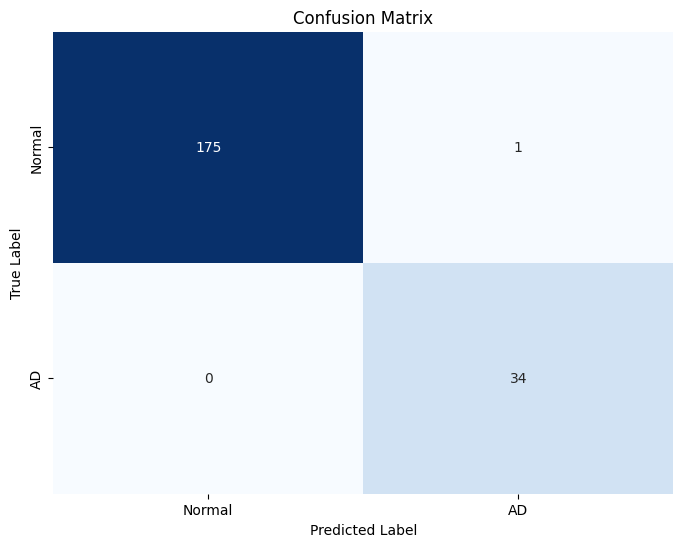

In [156]:
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Normal', 'AD'], yticklabels=['Normal', 'AD'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()